# Telco Customer Churn - Exploratory Data Analysis

This notebook performs exploratory data analysis on the Telco Customer Churn dataset.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries imported successfully!')

Libraries imported successfully!


## 1. Load the Dataset

In [4]:
# Load data
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Dataset loaded successfully!')
print(f'Shape: {df.shape}')

Dataset loaded successfully!
Shape: (7043, 21)


## 2. Initial Data Inspection

In [8]:
# Display first few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# Display last few rows
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
# Data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
# Statistical summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# Full summary (numeric + categorical)
df.describe(include='all')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [12]:
# Categorical-only summary
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [13]:
# Column names
print('Columns in the dataset:')
print(df.columns.tolist())

Columns in the dataset:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## 3. Data Quality Check

In [14]:
# Check for missing values
print('Missing values per column:')
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

Missing values per column:


,Missing Count,Percentage


In [15]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

Number of duplicate rows: 0


In [16]:
# Check data types
print('Data types:')
df.dtypes

Data types:


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [17]:
# Check TotalCharges column (should be numeric)
print('TotalCharges data type:', df['TotalCharges'].dtype)
print('\nSample values:')
print(df['TotalCharges'].head(10))

# Try to convert and check for issues
try:
    pd.to_numeric(df['TotalCharges'], errors='coerce')
    print('\nTotalCharges can be converted to numeric')
except:
    print('\nIssue with TotalCharges conversion')

# Check for non-numeric values
non_numeric = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna() & df['TotalCharges'].notna()]
print(f'\nRows with non-numeric TotalCharges: {len(non_numeric)}')

TotalCharges data type: object

Sample values:
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

TotalCharges can be converted to numeric

Rows with non-numeric TotalCharges: 11


## 4. Target Variable Analysis

In [18]:
# Churn distribution
print('Churn Distribution:')
print(df['Churn'].value_counts())
print('\nChurn Percentage:')
print(df['Churn'].value_counts(normalize=True) * 100)

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


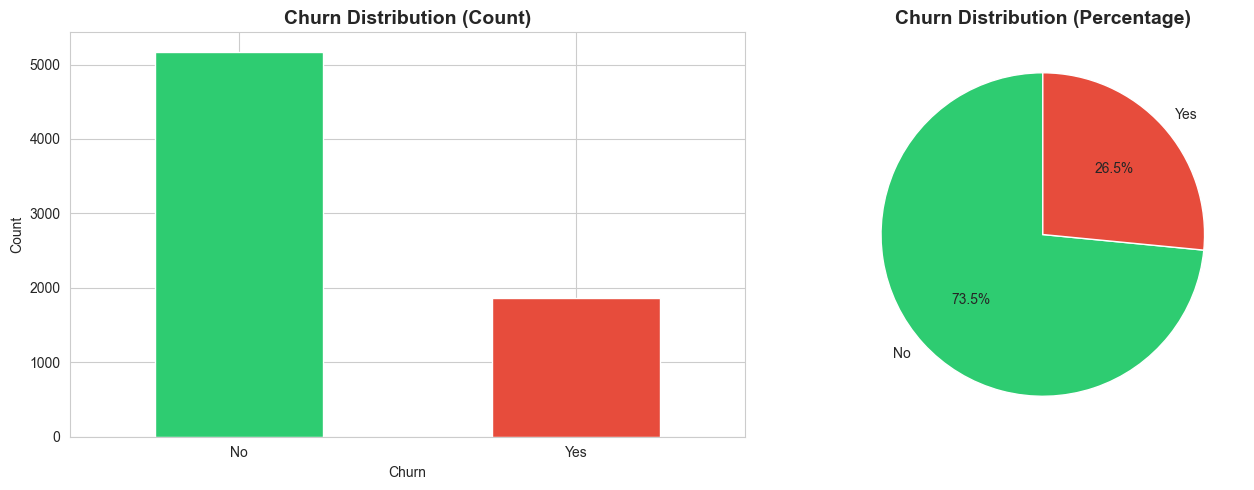


Dataset is imbalanced


In [19]:
# Visualize churn distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)

# Pie chart
df['Churn'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                 colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Churn Distribution (Percentage)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f'\nDataset is {"imbalanced" if df["Churn"].value_counts(normalize=True).max() > 0.7 else "balanced"}')

## 5. Numerical Features Analysis

In [20]:
# Identify numerical columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Statistical summary of numerical features
df[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


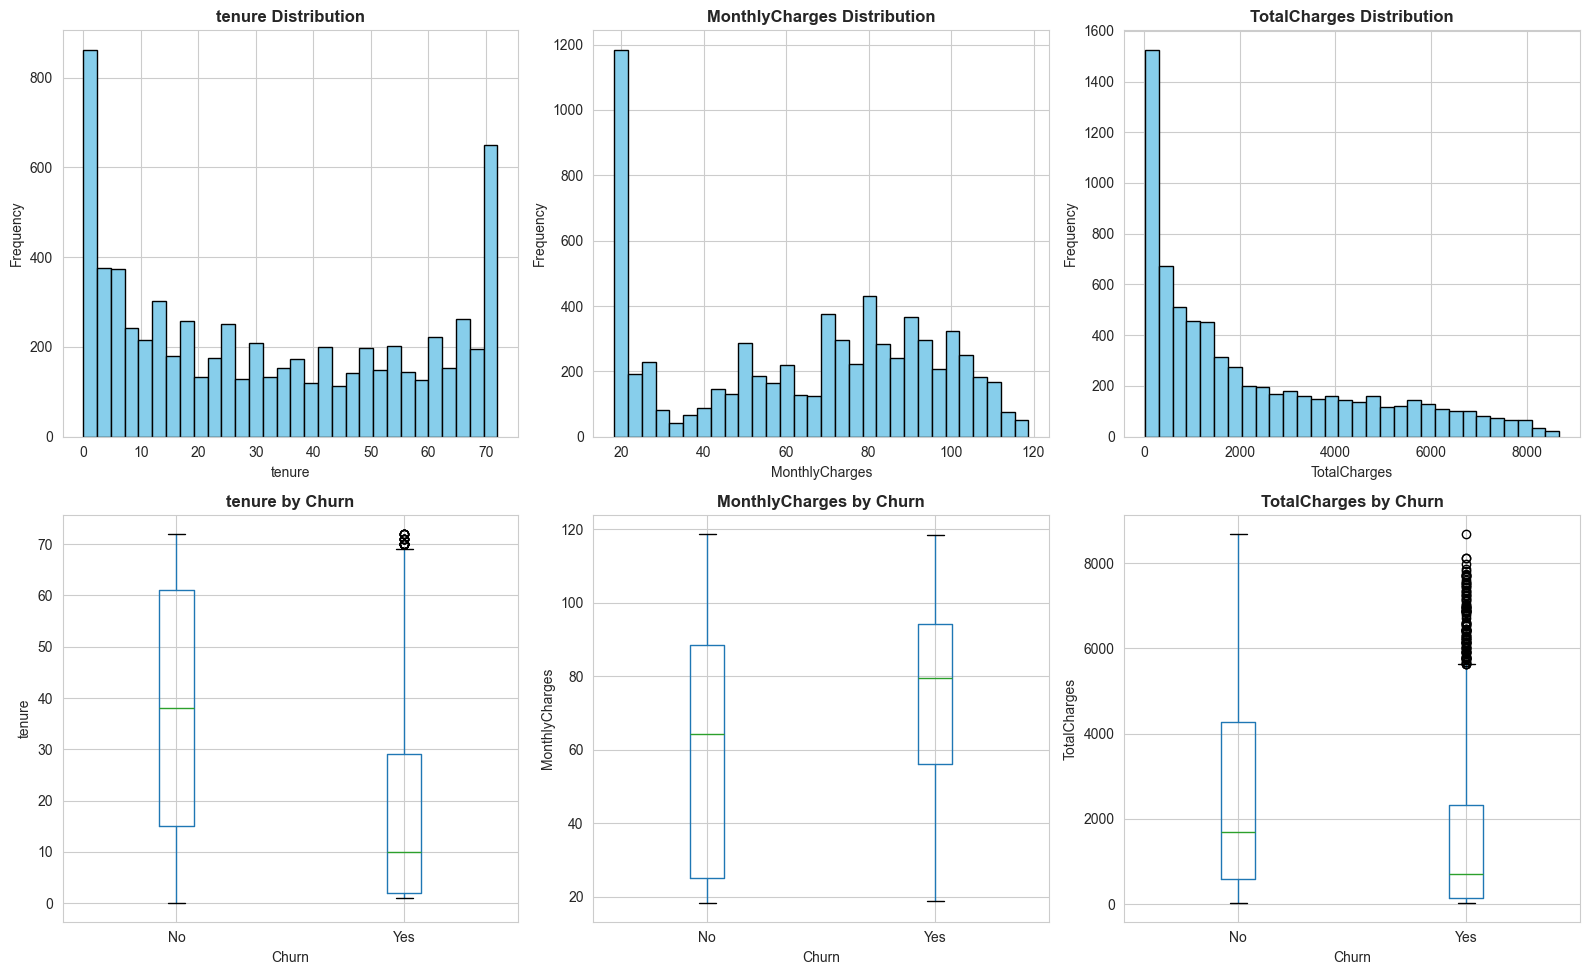

In [21]:
# Distribution of numerical features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for idx, col in enumerate(numerical_cols):
    row = idx // 3
    col_idx = idx % 3
    
    # Histogram
    axes[0, col_idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    axes[0, col_idx].set_title(f'{col} Distribution', fontweight='bold')
    axes[0, col_idx].set_xlabel(col)
    axes[0, col_idx].set_ylabel('Frequency')
    
    # Box plot by Churn
    df.boxplot(column=col, by='Churn', ax=axes[1, col_idx])
    axes[1, col_idx].set_title(f'{col} by Churn', fontweight='bold')
    axes[1, col_idx].set_xlabel('Churn')
    axes[1, col_idx].set_ylabel(col)
    plt.sca(axes[1, col_idx])
    plt.xticks([1, 2], ['No', 'Yes'])

plt.suptitle('')
plt.tight_layout()
plt.show()

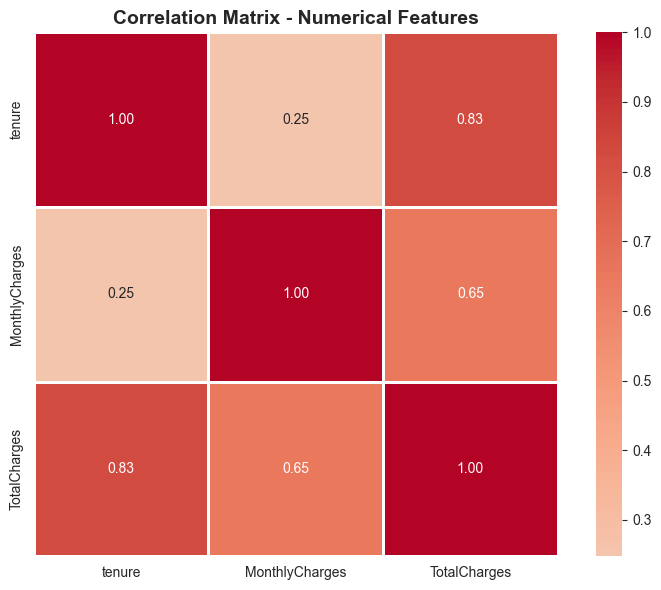


Correlation Matrix:
                 tenure  MonthlyCharges  TotalCharges
tenure          1.00000        0.247900      0.825880
MonthlyCharges  0.24790        1.000000      0.651065
TotalCharges    0.82588        0.651065      1.000000


In [22]:
# Correlation between numerical features
plt.figure(figsize=(8, 6))
correlation = df[numerical_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f')
plt.title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelation Matrix:')
print(correlation)

## 6. Categorical Features Analysis

In [23]:
# Identify categorical columns (excluding customerID and Churn)
categorical_cols = [col for col in df.columns if col not in numerical_cols + ['customerID', 'Churn']]

print(f'Number of categorical features: {len(categorical_cols)}')
print('\nCategorical features:')
for col in categorical_cols:
    print(f'- {col}: {df[col].nunique()} unique values')

Number of categorical features: 16

Categorical features:
- gender: 2 unique values
- SeniorCitizen: 2 unique values
- Partner: 2 unique values
- Dependents: 2 unique values
- PhoneService: 2 unique values
- MultipleLines: 3 unique values
- InternetService: 3 unique values
- OnlineSecurity: 3 unique values
- OnlineBackup: 3 unique values
- DeviceProtection: 3 unique values
- TechSupport: 3 unique values
- StreamingTV: 3 unique values
- StreamingMovies: 3 unique values
- Contract: 3 unique values
- PaperlessBilling: 2 unique values
- PaymentMethod: 4 unique values


In [24]:
# Value counts for each categorical feature
for col in categorical_cols:
    print(f'\n{col}:')
    print(df[col].value_counts())
    print('-' * 50)


gender:
gender
Male      3555
Female    3488
Name: count, dtype: int64
--------------------------------------------------

SeniorCitizen:
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
--------------------------------------------------

Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64
--------------------------------------------------

Dependents:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
--------------------------------------------------

PhoneService:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
--------------------------------------------------

MultipleLines:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
--------------------------------------------------

InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
--------------------------------------------------

OnlineSecurity:
OnlineS

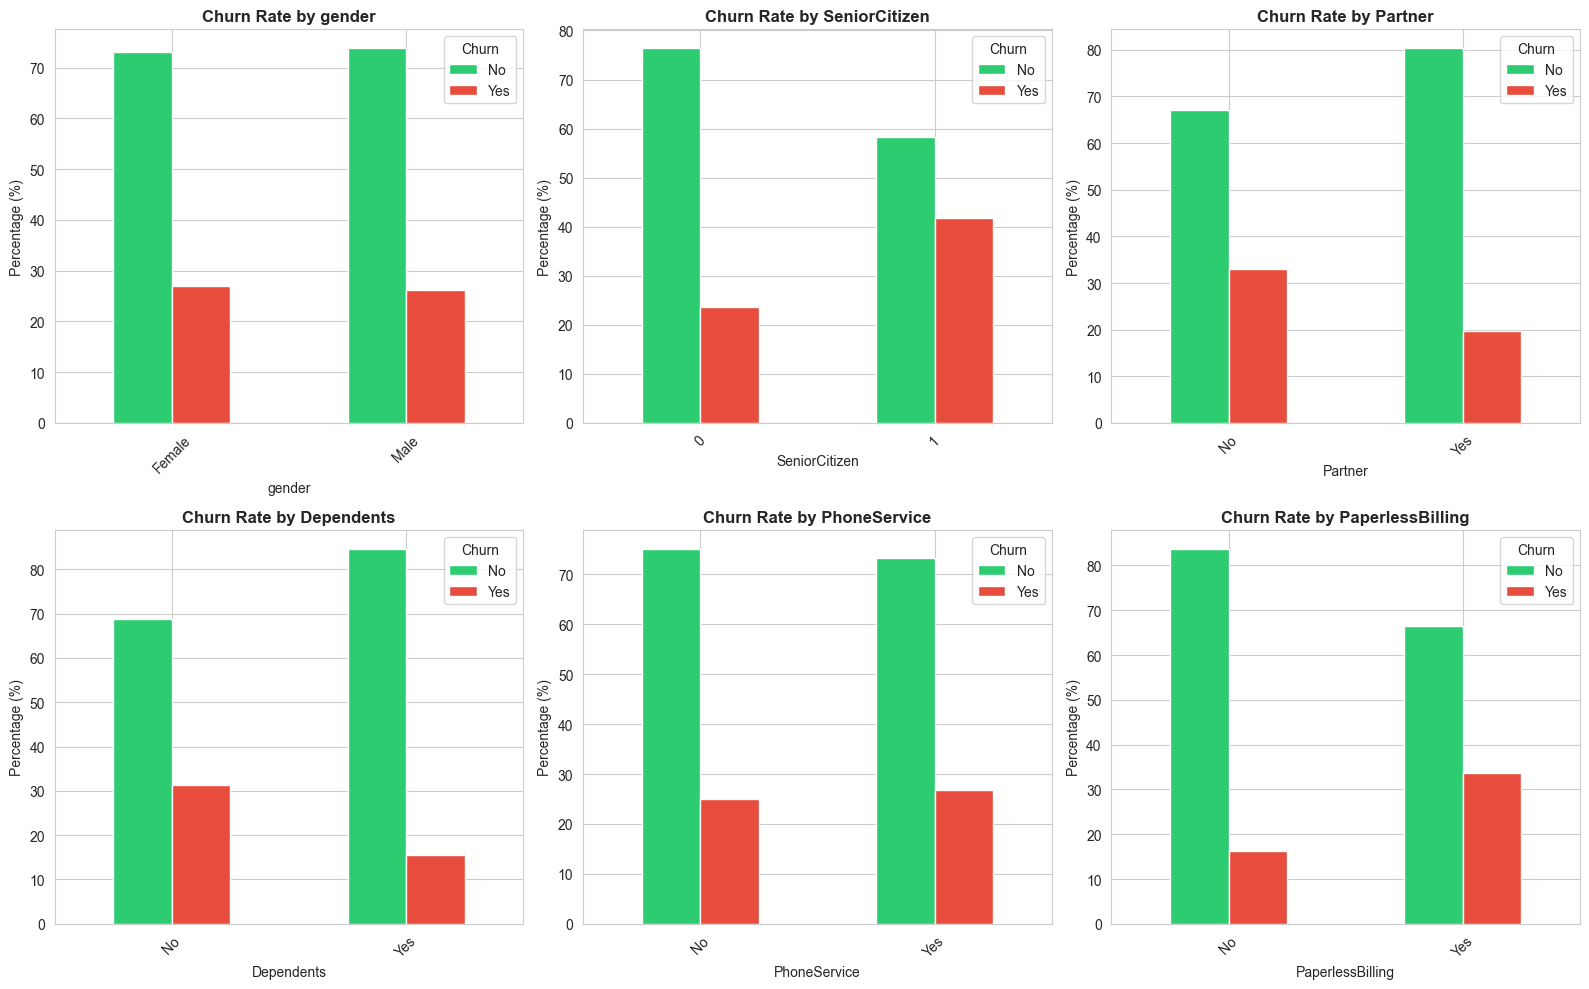

In [25]:
# Visualize categorical features vs Churn
# Binary categorical features
binary_cats = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(binary_cats):
    if col in df.columns:
        churn_data = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
        churn_data.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#e74c3c'])
        axes[idx].set_title(f'Churn Rate by {col}', fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Percentage (%)')
        axes[idx].legend(title='Churn', labels=['No', 'Yes'])
        axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

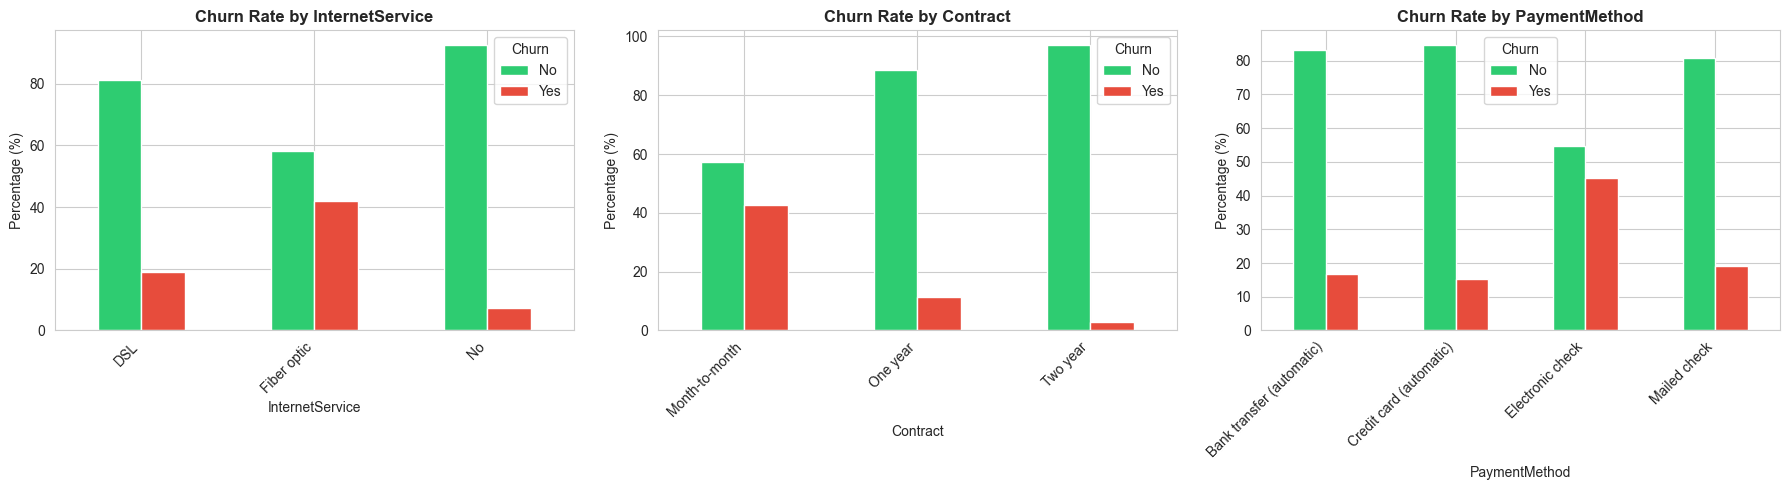

In [26]:
# Multi-value categorical features
multi_cats = ['InternetService', 'Contract', 'PaymentMethod']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(multi_cats):
    if col in df.columns:
        churn_data = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
        churn_data.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#e74c3c'])
        axes[idx].set_title(f'Churn Rate by {col}', fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Percentage (%)')
        axes[idx].legend(title='Churn', labels=['No', 'Yes'])
        axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

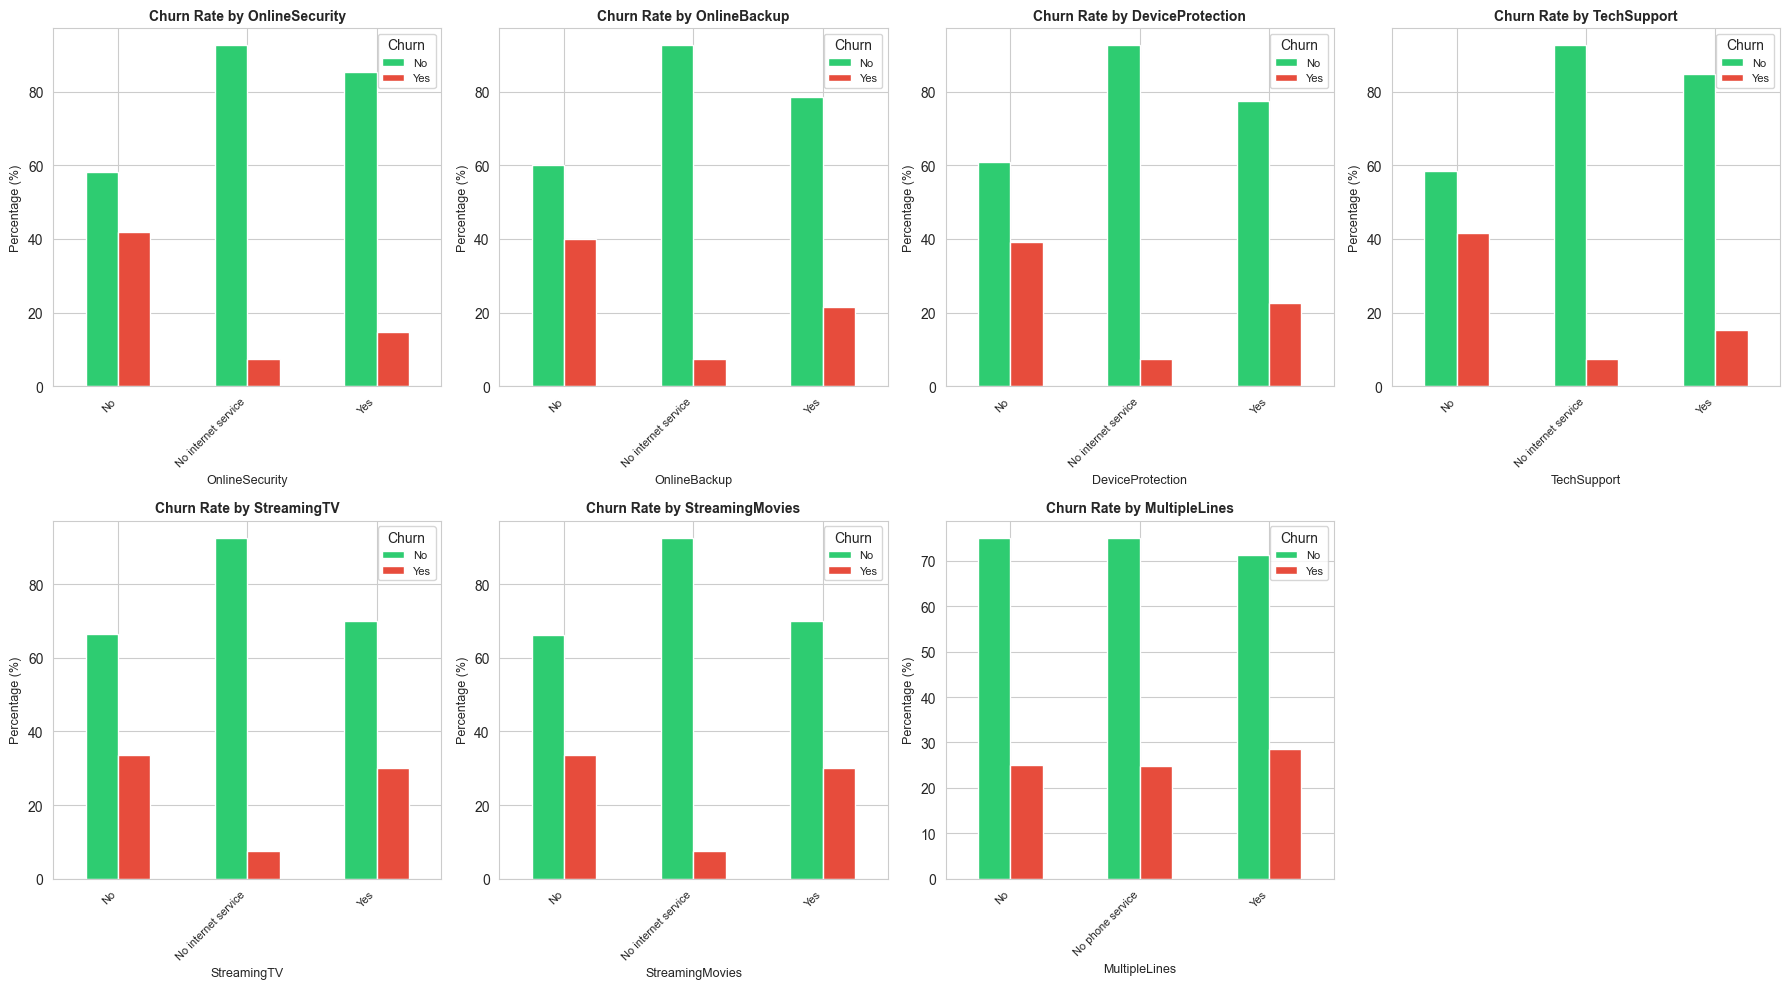

In [27]:
# Service-related features
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(service_cols):
    if col in df.columns:
        churn_data = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
        churn_data.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#e74c3c'])
        axes[idx].set_title(f'Churn Rate by {col}', fontweight='bold', fontsize=10)
        axes[idx].set_xlabel(col, fontsize=9)
        axes[idx].set_ylabel('Percentage (%)', fontsize=9)
        axes[idx].legend(title='Churn', labels=['No', 'Yes'], fontsize=8)
        axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right', fontsize=8)

# Hide the last subplot if not used
if len(service_cols) < 8:
    axes[7].axis('off')

plt.tight_layout()
plt.show()

## 7. Key Insights Summary

In [28]:
# Calculate churn rates for different segments
print('KEY INSIGHTS:')
print('=' * 60)

# Overall churn rate
overall_churn = (df['Churn'] == 'Yes').mean() * 100
print(f'\n1. Overall Churn Rate: {overall_churn:.2f}%')

# Churn by tenure
print('\n2. Churn Rate by Tenure:')
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], 
                             labels=['0-12 months', '12-24 months', '24-48 months', '48+ months'])
tenure_churn = df.groupby('tenure_group')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
print(tenure_churn)

# Churn by contract type
print('\n3. Churn Rate by Contract Type:')
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
print(contract_churn)

# Churn by monthly charges
print('\n4. Average Monthly Charges:')
print(f'   - Churned Customers: ${df[df["Churn"] == "Yes"]["MonthlyCharges"].mean():.2f}')
print(f'   - Retained Customers: ${df[df["Churn"] == "No"]["MonthlyCharges"].mean():.2f}')

# Churn by internet service
print('\n5. Churn Rate by Internet Service:')
internet_churn = df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
print(internet_churn)

print('\n' + '=' * 60)

KEY INSIGHTS:

1. Overall Churn Rate: 26.54%

2. Churn Rate by Tenure:
tenure_group
0-12 months     47.678161
12-24 months    28.710938
24-48 months    20.388959
48+ months       9.513176
Name: Churn, dtype: float64

3. Churn Rate by Contract Type:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

4. Average Monthly Charges:
   - Churned Customers: $74.44
   - Retained Customers: $61.27

5. Churn Rate by Internet Service:
InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn, dtype: float64



## 8. Data Quality Issues to Address

Based on the EDA, we need to address:
1. **TotalCharges**: Convert to numeric and handle missing/invalid values
2. **Feature Engineering**: Create tenure groups or other derived features if needed
3. **Encoding**: Convert categorical variables to numerical format
4. **Scaling**: Normalize numerical features for better model performance
5. **Class Imbalance**: Consider techniques like SMOTE or class weights if needed